# Finite Element Proceedures Notes

Largely based on [Finite Element Proceedures](https://www.google.com/books/edition/Finite_Element_Procedures/rWvefGICfO8C?hl=en&gbpv=1&pg=PR1&printsec=frontcover), by Klaus-Jurgen Bathe,  
examples performed in MIDAS.

[Web based PDF version](https://soaneemrana.org/onewebmedia/Finite%20Element%20Procedures%20in%20Engineering%20Analysis%20Bathe%20K.J.pdf)

## An Introduction to the Use of Finite Element Procedures

### Introduction

FEA Workflow:

```mermaid
---
config:
  theme: redux
  themeVariables:
    nodeSpacing: 100
---
flowchart TD
    A(["Physical Problem"]) --> B@{ label: "<b>Mathematical model</b><br>\n        Governed by differential equations<br>\n        <b>Assumptions on:</b><br>\n        <ul style=\"padding-left: 20px; text-align: left;\">\n            <li>Geometry</li>\n            <li>Kinematics</li>\n            <li>Material Law</li>\n            <li>Loading</li>\n            <li>Boundary Conditions</li>\n            <li>Etc.</li>\n        </ul>" }
    B -- Finite element solution of mathematical model --> C@{ label: "<b>Finite Element Solution</b><br><br>\n        <b>Choice of:</b><br>\n        <ul style=\"padding-left: 20px; text-align: left;\">\n            <li>Finite Elements</li>\n            <li>Mesh Density</li>\n            <li>Solution Parameters</li>\n        </ul><br>\n        <b>Representation of:</b><br>\n        <ul style=\"padding-left: 20px; text-align: left;\">\n            <li>Loading</li>\n            <li>Boundary Conditions</li>\n            <li>Etc.</li>\n        </ul>" }
    B ~~~ E["Refine mesh, solution parameters, etc."]
    subgraph "FEA"
    direction TB
        D["Assessment of accuracy of finite element solution of mathematical model"]
        C --> D
        E --> C
        D -- Not Accurate --> E
    end
    D -- Accurate --> F["Interpretation of results"]
    F --> G["Refine Analysis"] & I["Design Improvements Structural Optimization"]
    G -- Improve Mathematical Model --> B
    I -- Change of Physical Problem --> A
    B@{ shape: rect}
```

### Physical Problems, Mathematical Models, and the Finite Element Solution

This section was copied in its entirety for two reasons, it provides an  
introduction to the reader's first example problem, and perfectly  
illustrates the historical attitude towards advanced modeling practices.

`more advanced models = more effort = higher cost`

Rather than insisting that has historically been the attitude, I leave the  
author's words below as an an example of a primary source (an opinion which  
has also historically been accurate).

Most of the other other sections will be dedicated to working out the  
examples and theory in python, rather than the exact text of the source  
material, but I think it's important to start from this.

Lots of methods exist, with varying degrees of accuracy.

- Bernoulli beam theory
- Timoshenko beam theory
- two-dimensional plan stress theory
- three-dimensional continuum model

This is referred to as a hierarchy of models.

No model will predict what occurs in the real world with 100% accuracy, but  
all models are bad, some are useful.

It is commonly assumed the case that a fully three-dimensional analysis is  
about an order of magnitude more expensive (in computer resources and  
engineering time used) than a two-dimensional solution.

Example to consider,

Figure 1.2(a) shows a bracket used to support a vertical load. For the  
analysis, we need to choose a mathematical model. This choice must clearly  
depend on what phenomena are to be predicted and on the geometry, material  
properties, loading, and support conditions of the bracket.

We have indicated in Fig. 1.2(a) that the bracket is fastened to a very  
thick steel column. The description "very thick" is of course relative to  
the thickness t and the height h of the bracket. We translate this  
statement into the assumption that the bracket is fastened to a  
(practically) rigid column. Hence we can focus our attention on the bracket  
by applying a "rigid column boundary condition" to it. (Of course, at a  
later time, an analysis of the column may be required, and then the loads  
carried by the two bolts, as a consequence of the load W, will need to be  
applied to the column.) 

We also assume that the load W is applied very slowly. The condition of  
time "very slowly" is relative to the largest natural period of the  
bracket; that is, the time span over which the load W is increased from  
zero to its full value is much longer than the fundamental period of the  
bracket. We translate this statement into requiring a static analysis (and  
not a dynamic analysis).

With these preliminary considerations we can now establish an appropriate  
mathematical model for the analysis of the bracket-depending on what  
phenomena are to be predicted. Let us assume, in the first instance, that  
only the total bending moment at section AA in the bracket and the  
deflection at the load application are sought. To predict these quantities,  
we consider a beam mathematical model including shear deformations [see  
Fig. 1.2(b)] and obtain;

$$ M = WL \tag{1.1} $$

$$ \delta \rvert_{at\ load\ W} = \frac{1}{3} \frac{W(L+r_N)^3}{EI} + \frac{W(L+r_N)}{\frac{5}{6}AG} \tag{1.2} $$

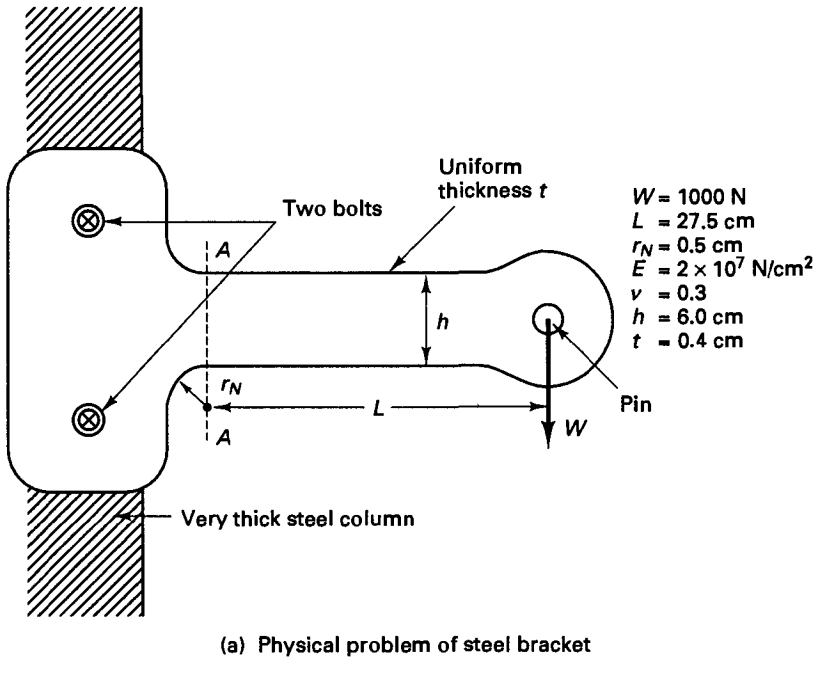

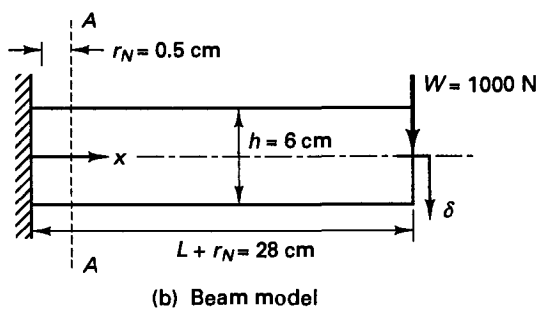

<center><b>Figure 1.2 Bracket to be analyzed and two mathematical models</b></center>

In [3]:
from civilpy.general import units

In [4]:
W = 1000 * units('N')
L = 27.5 * units('cm')
r_N = 0.5 * units('cm')
E = 2e7 * units('N/cm^2')
v = 0.3
h = 6 * units('cm')
t = 0.4 * units('cm')
G = 200 * units('GPa')

M = W * L
I = 1/3 * t * h ** 3
A = h * t

In [5]:
delta_at_load_W = (1/3) * (W * (L + r_N) ** 3) / (E * I) + (W * (L + r_N)) / ((5/6) * A * G)

In [6]:
print(f"{M} (1.1)")
print(f"{delta_at_load_W} (1.2)")  # Note - I think this is wrong in the original book... 
# //TODO - Check my calc here

27500.0 centimeter * newton (1.1)
0.013403703703703702 centimeter (1.2)


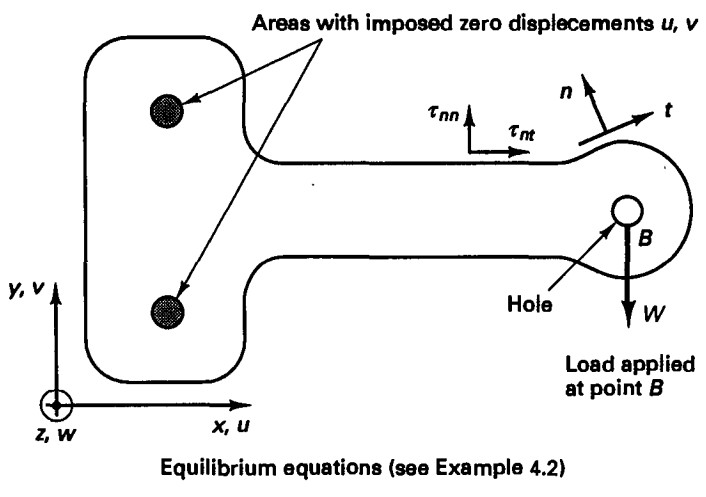

$$
\begin{aligned}
\frac{\partial \tau_{xx}}{\partial x} + \frac{\partial \tau_{xy}}{\partial y} &= 0 \\
\frac{\partial \tau_{yx}}{\partial x} + \frac{\partial \tau_{yy}}{\partial y} &= 0 
\end{aligned}
\qquad \Bigg\} \text{in domain of bracket}  % Brace and text
$$

$ \tau_{nn} = 0 $, $ \tau_{nt} = 0 $ on surfaces except at point B and at imposed zero displacements. 

Stress-strain relation (see Table 4.3):

$$
\begin{bmatrix}
\tau_{xx} \\
\tau_{yy} \\
\tau_{xy} \\
\end{bmatrix} = \frac{E}{1 - v^2}
\begin{bmatrix}
1 & v & 0 \\
v & 1 & 0 \\
0 & 0 & \frac{1-v}{2} \\
\end{bmatrix}
\begin{bmatrix}
\epsilon_{xx} \\
\epsilon_{yy} \\
\epsilon_{xy} \\
\end{bmatrix}
$$

$ E $ = Young's Modulus, $ v $ = Poisson's ratio

Strain-displacement relations (see Section 4.2):

$$ \epsilon_{xx} = \frac{\partial u}{\partial x}; \qquad \epsilon_{yy} = \frac{\partial v}{\partial y}; \qquad \gamma_{xy} = \frac{\partial u}{\partial y} + \frac{\partial v}{\partial x} $$
<center><b>(c) Plane stress model</b></center>
<center><b>Figure 1.2 (continued)</b></center>

where $L$ and $r$ are given in Fig. 1.2(a), $E$ is the Young's modulus of the  
steel used, $G$ is the shear modulus, $I$ is the moment of inertia of the  
bracket arm ($ I=\frac{1}{12}h^3t $), $A$ is the crosssectional area ($ A = ht $), and the  
factor is a shear correction factor (see Section 5.4.1).

Of course, the relations in (1.1) and (1.2) assume linear elastic  
infinitesimal displacement conditions, and hence the load must not be so  
large as to cause yielding of the material and/or large displacements.

Let us now ask whether the mathematical model used in Fig. 1.2(b) was  
reliable and effective. To answer this question, strictly, we should  
consider a very-comprehensive mathematical model, which in this case would  
be a fully three-dimensional representation of the full bracket. This model  
should include the two bolts fastening the bracket to the (assumed rigid)  
column as well as the pin through which the load W is applied. The three-  
dimensional solution of this model using the appropriate geometry and  
material data would give the numbers against which we would compare the  
answers given in (1.1) and (1.2). Note that this three-dimensional  
mathematical model contains contact conditions (the contact is between the  
bolts, the bracket, and the column, and between the pin carrying the load  
and the bracket) and stress concentrations in the fillets and at the holes.  
Also, if the stresses are high, nonlinear material conditions should be  
included in the model. Of course, an analytical solution of this  
mathematical model is not available, and all we can obtain is a numerical  
solution. We describe in this book how such solutions can be calculated  
using finite element procedures, but we may note here already that the  
solution would be relatively expensive in terms of computer resources and  
engineering time used. 

Since the three-dimensional comprehensive mathematical model is very likely  
toо comprehensive a model (for the analysis questions we have posed), we  
instead may consider a linear elastic two-dimensional plane stress model as  
shown in Fig. 1.2(c). This mathematical model represents the geometry of  
the bracket more accurately than the beam model and assumes a two-  
dimensional stress situation in the bracket (see Section 4.2). The bending  
moment at section AA and deflection under the load calculated with this  
model can be expected to be quite close to those calculated with the very-  
comprehensive three dimensional model, and certainly this two-dimensional  
model represents a higher-order model against which we can measure the  
adequacy of the results given in (1.1) and (1.2). Of course, an analytical  
solution of the model is not available, and a numerical solution must be  
sought.

Figures 1.3(a) to (e) show the geometry and the finite element  
discretization used in the solution of the plane stress mathematical model  
and some stress and displacement results obtained with this discretization.  
Let us note the various assumptions of this mathematical model when  
compared to the more comprehensive three-dimensional model discussed  
earlier. Since a plane stress condition is assumed, the only nonzero  
stresses are $\tau_{xx}$, $\tau_{yy}$, and $\tau_{xy}$. Hence we assume that the stresses $\tau_{zz}$, $\tau_{yz}$,  
and $\tau_{zx}$ are zero. Also, the actual bolt fastening and contact conditions  
between the steel column and the bracket are not included in the model, and  
the pin carrying the load into the bracket is not modeled. However, since  
our objective is only to predict the bending moment at section AA and the  
deflection at point B, these assumptions are deemed reasonable and of  
relatively little influence.

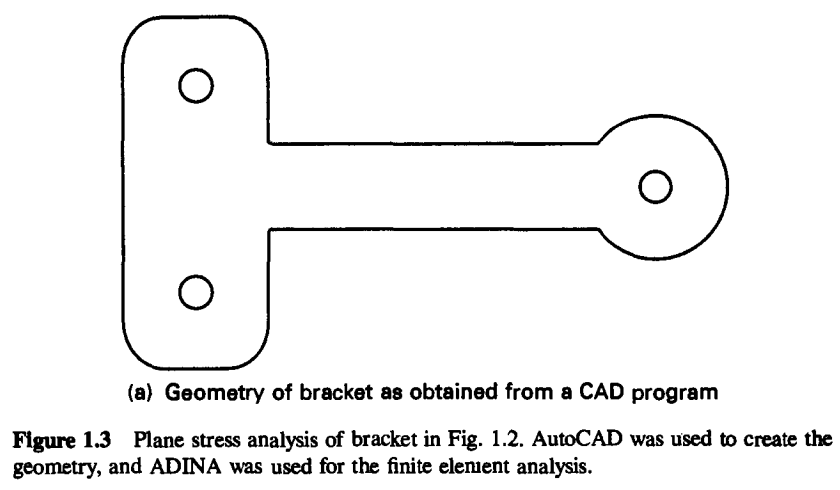

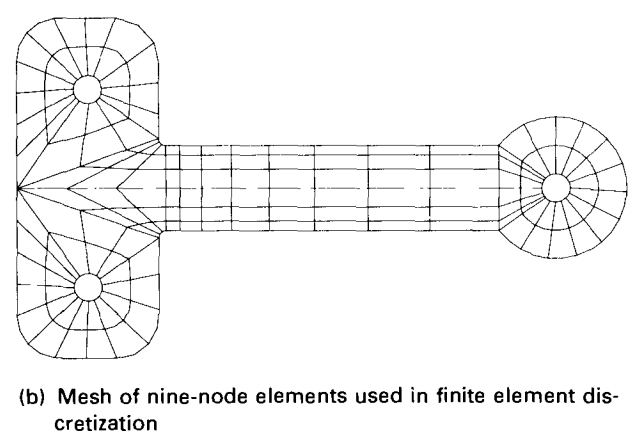

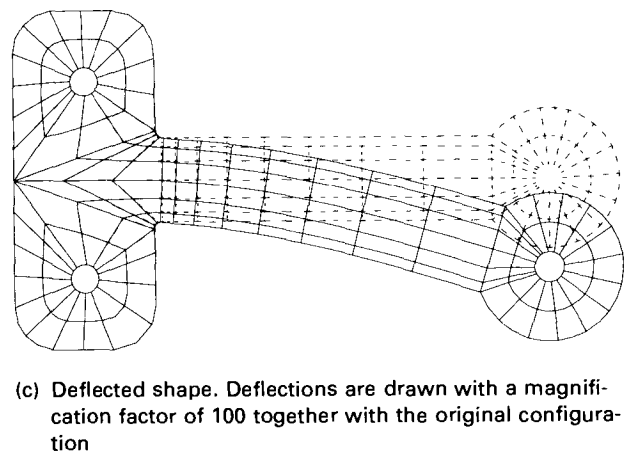

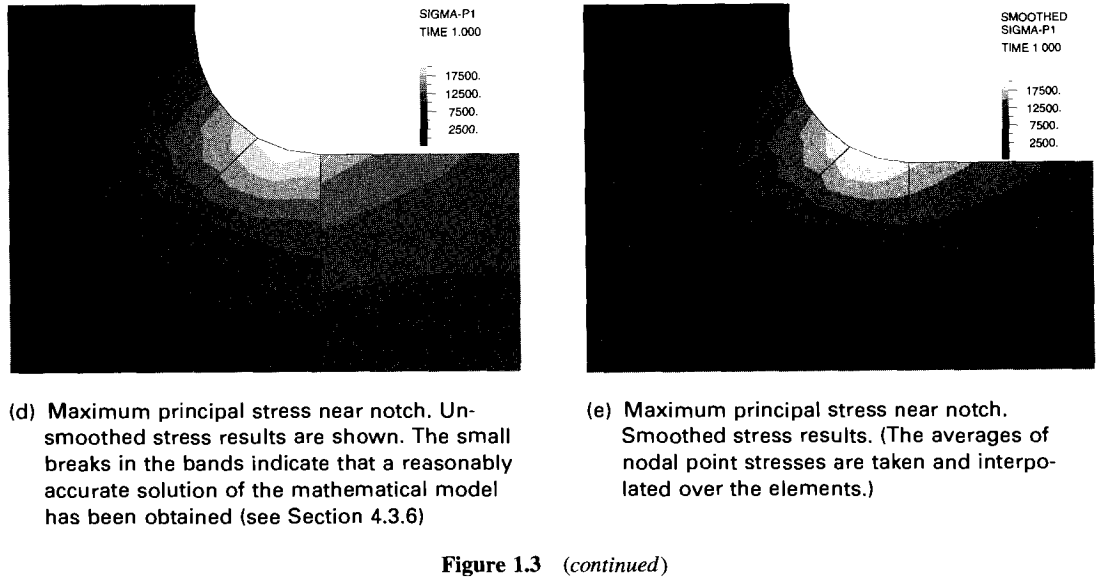

Let us assume that the results obtained in the finite element solution of  
the mathematical model are sufficiently accurate that we can refer to the  
solution given in Fig. 1.3. as the solution of the plane stress  
mathematical model.

Figure 1.3(c) shows the calculated deformed configuration. The deflection  
at the point of load application B as predicted in the plane stress  
solution is;

$$ \delta \rvert_\text{at load W} = 0.64\ cm \tag{1.3} $$

Also, the total bending moment predicted at section AA is;

$$ \delta \rvert_{x=0} = 27,500\ N\ cm \tag{1.4} $$

Whereas the same magnitude of bending moment at section AA is predicted by  
the beam model and the plane stress model<sup>(1)</sup>, the deflection of the beam model is  
considerably less than that predicted by the plane stress model (because of  
the assumption that the beam in Fig. 1.2(b) is supported rigidly at its  
left end, which neglects any deformation between the beam end and the  
bolts).

Considering these results, we can say that the beam mathematical model in  
Fig. 1.2(b) is reliable if the required bending moment is to be predicted  
within 1 percent and the deflection is to be predicted only within 20  
precent accuracy. The beam model is of course also effective because the  
calculations are performed with very little effort.

On the other hand, if we next ask for the maximum stress in the bracket,  
then the simple mathematical beam model in Fig. 1.2(b) will not yield a  
sufficiently accurate answer. Specifically, the beam model totally neglects  
the stress increase due to the fillets<sup>(2)</sup>. Hence a plane stress solution  
including the fillets is necessary.

The important points to note here are the following

- The selection of the mathematical model must depend on the response to  
be predicted (i.e., on the questions asked of nature).
- The most effective mathematical model is that one which delivers the  
answers to the questions in a reliable manner (i.e., within an acceptable  
error) with the least amount of effort.
- A finite element solution can solve accurately only the chosen  
mathematical model (e.g., the beam model or the plane stress model in Fig.  
1.2) and cannot predict any more information than that contained in the  
model.
- The notion of reliability of the mathematical model hinges upon an  
accuracy assessment of the results obtained with the chosen mathematical  
model (in response to the questions asked) against the results obtained  
with the very-comprehensive mathematical model. However, in practice the  
very-comprehensive mathematical model is usually not solved, and instead  
engineering experience is used, or a more refined mathematical model is  
solved, to judge whether the mathematical model used was adequate (i.e.,  
reliable) for the response to be predicted.


<!-- # //TODO - Try to make these more citationy -->
> 1\) The bending moment at section AA in the plane stress model is  
calculated here from the finite element nodal point forces, and for  
this statically determinate analysis problem the internal resisting  
moment must be equal to the externally applied moment (see Example  
4.9)  

> 2\) Of course, the effect of the fillets could be estimated by the  
use of stress concentration factors that have been established from  
plane stress solutions.

Finally, there is one further important general point. The chosen  
mathematical model may contain extremely high stresses because of sharp  
corners, concentrated loads, or other effects. These high stresses may be  
due solely to the simplifications used in the model when compared with the  
very-comprehensive mathematical model (or with nature). For example, the  
concentrated load in the plane stress model in Fig. 1.2(c) is an  
idealization of a pressure load over a small area. (This pressure would in  
nature be transmitted by the pin carrying the load into the bracket.) The  
exact solution of the mathematical model in Fig. 1.2(c) gives an infinite  
stress at the point of load application, and we must therefore expect a  
very large stress at point B as the finite element mesh is refined. Of  
course, this very large stress is an artifice of the chosen model, and the  
concentrated load should be replaced by a pressure load over a small area  
when a very fine discretization is used (see further discussion).  
Furthermore, if the model then still predicts a very high stress, a  
nonlinear mathematical model would be appropriate.

Note that the concentrated load in the beam model in Fig. 1.2(b) does not  
introduce any solution difficulties. Also, the right-angled sharp corners  
at the support of the beam model, of course, do not introduce any solution  
difficulties, whereas such corners in a plane stress model would introduce  
infinite stresses. Hence, for the plane stress model, the corners have to  
be rounded to more accurately represent the geometry of the actual physical  
bracket. 

We thus realize that the solution of a mathematical model may result in  
artificial difficulties that are easily removed by an appropriate change in  
the mathematical model to more closely represent the actual physical  
situation. Furthermore, the choice of a more encompassing mathematical  
model may result, in such cases, in a decrease in the required solution  
effort.

While these observations are of a general nature, let us consider once  
again, specifically, the use of concentrated loads. This idealization of  
load application is extensively used in engineering practice. We now  
realize that in many mathematical models (and therefore also in the finite  
element solutions of these models), such loads create stresses of infinite  
value. Hence, we may ask under what conditions in engineering practice  
solution difficulties may arise. We find that in practice solution  
difficulties usually arise only when the finite element discretization is  
very fine, and for this reason the matter of infinite stresses under  
concentrated loads is frequently ignored. As an example, Fig. 1.4 gives  
finite element results obtained in the analysis of a cantilever, modeled as  
a plane stress problem. The cantilever is subjected to a concentrated tip  
load. In practice, the 6 X 1 mesh is usually considered sufficiently fine,  
and clearly, a much finer discretization would have to be used to  
accurately show the effects of the stress singularities at the point of  
load application and at the support. As already pointed out, if such a  
solution is pursued, it is necessary to change the mathematical model to  
more accurately represent the actual physical situation of the structure.  
This change in the mathematical model may be important in self-adaptive  
finite element analyses because in such analyses new meshes are generated  
automatically and artificial stress singularities cause—artificially—  
extremely fine discretizations.

We refer to these considerations in Section 4.3.4 when we state the general  
elasticity problem considered for finite element solution.

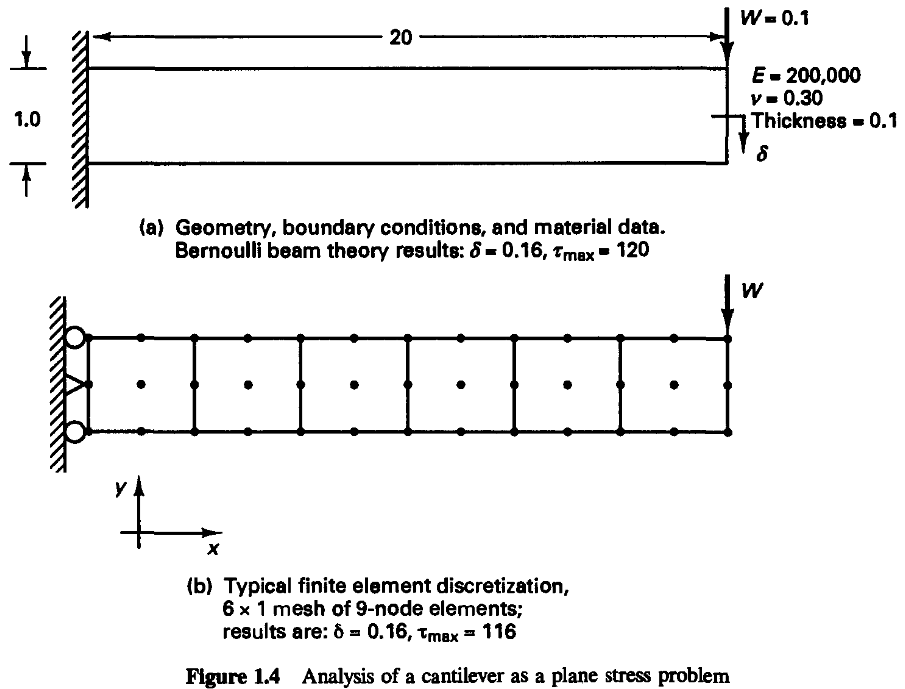

In summary, we should keep firmly in mind that the crucial step in any  
finite element analysis is always choosing an appropriate mathematical  
model since a finite element solution solves only this model. Furthermore,  
the mathematical model must depend on the analysis questions asked and  
should be reliable and effective (as defined earlier). In the process of  
analysis, the engineer has to judge whether the chosen mathematical model  
has been solved to a sufficient accuracy and whether the chosen  
mathematical model was appropriate (i.e., reliable) for the questions  
asked. Choosing the mathematical model, solving the model by appropriate  
finite element procedures, and judging the results are the fundamental  
ingredients of an engineering analysis using finite element methods.

### Finite Element Analysis as an Integral Part of Computer-Aided Engineering

Although the focus here is on analysis, it's important to rememeber that  
in general all analysis is done in support of design in some way.

Any methods used have to be reliable robust and efficient.

Problem solving with computers is an iterative process. You set a series of  
parameters, have the computer solve the equation, check the result, and  
then determine if further optimization of the parameters is required.

### Some Recent Research Accomplishments

This sections varies between versions with version 2's title shown here. V1  
discusses how to study finite element methods.

The research discussed focuses mainly on speed, efficiency and addressing  
edge cases in the world of finite element analysis. The author discusses  
shells and the complexities that arise when modeling real objects in a  
virtual process and what kinds of assumptions and comprimises have to be  
made.

He touches on the fluid structure interaction as being a potential source  
for future research as it's a rapidly growing field.

See the pdf link for recommendations for studying FEA as far as literature.

## Vectors, Matrices and Tensors

### Introduction

### Introduction to Matrices

### Vector Spaces

### Definition of Tensors

### The Symmetric Eigenproblem $ A\text{v}= \lambda\text{v}$

### The Rayleigh Quotient and the Minimax Characterization of Eigenvalues

### Vector and Matrix Norms

### Exercises

## Some Basic Concepts of Engineering Analysis and an Introduction to the Finite Element Method

### Introduction

### Solution of Discrete-System Mathematical Models

#### Steady-State Problems

#### Propagation Problems

#### Eigenvalue Problems

#### On the Nature of Solutions

#### Exercises

## Formulation of the Finite Element Method - Linear Analysis in Solid and Structural Mechanics

### Introduction

### Formulation of the Displacement-Based Finite Element Method

#### General Derivation of Finite Element Equilibrium Equations

#### Imposition of Displacement Boundary Conditions

#### Generalized Coordinate Models for Specific Problems

#### Lumping of Structure Properties and Loads


#### Exercises

### Convergence of Analysis Results

#### The Model Problem and a Definition of Convergence

#### Criteria for Monotonic Convergence

#### The Monotonically Convergent Finite Element Solution: A Ritz Solution


#### Properties of the Finite Element Solution


#### 4.3.5 Rate of Convergence

#### Calculation of Stresses and the Assessment of Error


#### Exercises

### Incompatible and Mixed Finite Element  

#### Incompatible Displacement-Based Models

#### Mixed Formulations

#### Mixed Interpolation-Displacement/Pressure Formulations for Incompressible Analysis

#### Exercises

### The Inf-Sup Condition for Analysis of Incompressible Media and Structural Problems

#### The Inf-Sup Condition Derived from Convergence Considerations

#### The Inf-Sup Condition Derived from the Matrix Equations


#### The Constant (Physical) Pressure Mode

#### Spurious Pressure Modes-The Case of Total Incompressibility

#### Spurious Pressure Modes-The Case of Near Incompressibility

#### The Inf-Sup Test

#### An Application to Structural Elements: The Isoparametric Beam Elements

#### Exercises


## Formulation and Calculation of Isoparametric Finite Element Matrices

### Introduction

### Isoparametric Derivation of Bar Element Stiffness Matrix

### Formulation of Continuum Elements

#### Quadrilateral Elements

#### Triangular Elements

#### Convergence Considerations

#### Element Matrices in Global Coordinate System

#### Displacement/Pressure Based Elements for Incompressible Media

#### Exercises

### Formulation of Structural Elements

#### Beam and Axisymmetric Shell Elements

#### Plate and General Shell Elements

#### Exercises

### Numerical Integration

#### Interpolation Using a Polynomial

#### The Newton-Cotes Formulas (One-Dimensional Integration)

#### The Gauss Formulas (One-Dimensional Integration)

#### Integrations in Two and Three Dimensions

#### Appropriate Order of Numerical Integration

#### Reduced and Selective Integration

#### Exercises

### Computer Program Implementation of Isoparametric Finite Elements

## Finite Element Nonlinear Analysis in Solid and Structural Mechanic

### Introduction to Nonlinear Analysis

### Formulation of the Continuum Mechanics Incremental Equations of Motion

#### The Basic Problem

#### The Deformation Gradient, Strain, and Stress Tensors

#### Continuum Mechanics Incremental Total and Updated Lagrangian Formulations, Materially-Nonlinear-Only Analysis

#### Exercises

### Displacement-Based Isoparametric Continuum Finite Elements

#### Linearization of the Principle of Virtual Work with Respect to Finite Element Variables

#### General Matrix Equations of Displacement-Based Continuum Elements

#### Truss and Cable Elements

#### Two-Dimensional Axisymmetric, Plane Strain, and Plane Stress Elements

#### Three-Dimensional Solid Elements

#### Exercises

### Displacement/Pressure Formulations for Large Deformations

#### Total Lagrangian Formulation

#### Updated Lagrangian Formulation

#### Exercises

### Structural Elements


#### Beam and Axisymmetric Shell Elements

#### Plate and General Shell Elements

#### Exercises

### Use of Constitutive Relations 581

#### Elastic Material Behavior-Generalization of Hooke's Law

#### Rubberlike Material Behavior

#### Inelastic Material Behavior; Elastoplasticity, Creep, and Viscoplasticity

#### Large Strain Elastoplasticity

#### Exercises

### Contact Conditions

#### Continuum Mechanics Equations

#### A Solution Approach for Contact Problems: The Constraint Function Method

#### Exercises

### Some Practical Considerations

#### The General Approach to Nonlinear Analysis

#### Collapse and Buckling Analyses

#### The Effects of Element Distortions

#### The Effects of Order of Numerical Integration

#### Exercises

## Finite Element Analysis of Heat Transfer, Field Problems, and Incompressible Fluid Flows

### Introduction

### Heat Transfer Analysis

#### Governing Heat Transfer Equations

#### Incremental Equations

#### Finite Element Discretization of Heat Transfer Equations

#### Exercises

### Analysis of Field Problems

#### Seepage

#### Incompressible Inviscid Flow

#### Torsion

#### Acoustic Fluid

#### Exercises

### Analysis of Viscous Incompressible Fluid Flows

#### Continuum Mechanics Equations

#### Finite Element Governing Equations

#### High Reynolds and High Peclet Number Flows

#### Exercises

## Solution of Equilibrium Equations in Static Analysis

### Introduction

### Direct Solutions Using Algorithms Based on Gauss Elimination

#### Introduction to Gauss Elimination

#### The LDLT Solution

#### Computer Implementation of Gauss Elimination--The Active Column Solution

#### Cholesky Factorization, Static Condensation, Substructures, and Frontal Solution

#### Positive Definiteness, Positive Semidefiniteness, and the Sturm Sequence Property

#### Solution Errors

#### Exercises

### Iterative Solution Methods

#### The Gauss-Seidel Method

#### Conjugate Gradient Method with Preconditioning


#### Exercises

### Solution of Nonlinear Equations

#### Newton-Raphson Schemes

#### The BFGS Method

#### Load-Displacement-Constraint Methods

#### Convergence Criteria

#### Exercises

## Solution of Equilibrium Equations in Dynamic Analysis

### Introduction

### Direct Integration Methods

#### The Central Difference Method

#### The Houbolt Method

#### The Wilson 0 Method

#### The Newmark Method

#### The Coupling of Different Integration Operators

#### Exercises

### Mode Superposition

#### Change of Basis to Modal Generalized Displacements

#### Analysis with Damping Neglected

#### Analysis with Damping Included

#### Exercises

### Analysis of Direct Integration Methods

#### Direct Integration Approximation and Load Operators

#### Stability Analysis

#### Асcuracy Analysis

#### Some Practical Considerations

#### Exercises

### Solution of Nonlinear Equations in Dynamic Analysis

#### Explicit Integration

#### Implicit Integration

#### Solution Using Mode Superposition

#### Exercises

### Solution of Nonstructural Problems; Heat Transfer and Fluid Flows

#### The a-Method of Time Integration

#### Exercises

## Preliminaries to the Solution of Eigenproblems

### Introduction

### Fundamental Facts Used in the Solution of Eigensystems

#### Properties of the Eigenvectors

#### The Characteristic Polynomials of the Eigenproblem Kф = AMФ and of Its Associated Constraint Problems

#### Shifting

#### Effect of Zero Mass

#### Transformation of the Generalized Eigenproblem Kφ = λΜφ to a Standard Form

#### Exercises

### Approximate Solution Techniques

#### Static Condensation

#### Rayleigh-Ritz Analysis

#### Component Mode Synthesis

#### Exercises

### Solution Errors

#### Error Bounds

#### Exercises

## Solution Methods for Eigenproblems

### Introduction

### Vector Iteration Methods

#### Inverse Iteration

#### Forward Iteration

#### Shifting in Vector Iteration

#### Rayleigh Quotient Iteration

#### Matrix Deflation and Gram-Schmidt Orthogonalization

#### Some Practical Considerations Concerning Vector Iterations

#### Exercises

### Transformation Methods




#### The Jacobi Method

#### The Generalized Jacobi Method

#### The Householder-QR-Inverse Iteration Solution

#### Exercises

### Polynomial Iterations and Sturm Sequence Techniques

#### Explicit Polynomial Iteration

#### Implicit Polynomial Iteration

#### Iteration Based on the Sturm Sequence Property

#### Exercises

### The Lanczos Iteration Metho

#### The Lanczos Transformation

#### Iteration with Lanczos Transformations

#### Exercises

### The Subspace Iteration Method

### Preliminary Considerations

### Subspace Iteration

### Starting Iteration Vectors

### Convergence

### Implementation of the Subspace Iteration Method

### Exercises

## Implementation of the Finite Element Method

### Introduction

### Computer Program Organization for Calculation of System Matrices

#### Nodal Point and Element Information Read-in

#### Calculation of Element Stiffness, Mass, and Equivalent Nodal Loads

#### Assemblage of Matrices

### Calculation of Element Stresses

### Example Program STAP

#### Data Input to Computer Program STAP

#### Listing of Program STАP

### Exercises and Projects

# References

# Index